## CNN Text Classification on Handwritten Digits

In [1]:
# import libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import matplotlib.pyplot as plt

In [2]:
from torchvision import datasets, transforms

 # loads as (1, 28, 28) and normalizes to [0,1]
transform = transforms.ToTensor()

train_data = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_data  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=64, shuffle=False)

In [3]:
# building CNN model
def build_cnn(stride=1, pooling_type='max', num_filters=32):

    if pooling_type == 'max':
        pooling = nn.MaxPool2d(2, 2)
    else:
        pooling = nn.AvgPool2d(2, 2)

    conv_block = nn.Sequential(
        nn.Conv2d(1, num_filters,       kernel_size=3, stride=stride, padding=1), nn.ReLU(),
        pooling,
        nn.Conv2d(num_filters, num_filters*2, kernel_size=3, stride=stride, padding=1), nn.ReLU(),
        pooling,
    )

    # Dynamically compute flattened size
    with torch.no_grad():
        dummy = torch.zeros(1, 1, 28, 28)
        flat_size = conv_block(dummy).numel()

    model = nn.Sequential(
        *conv_block,
        nn.Flatten(),
        nn.Linear(flat_size, 128), nn.ReLU(),
        nn.Linear(128, 10)
    )
    return model

In [4]:
# helper functions

def train_model(model, epochs=5):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters())

    history = []

    for epoch in range(epochs):
        model.train()
        correct, total = 0, 0

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()

            out = model(X_batch)
            loss = criterion(out, y_batch)

            loss.backward()
            optimizer.step()

            correct += (out.argmax(1) == y_batch).sum().item()
            total += len(y_batch)

        acc = correct / total
        history.append(acc)

        print(f"Epoch {epoch+1}, Accuracy={acc:.4f}")

    return model, history

def evaluate_model(model):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            out = model(X_batch)
            correct += (out.argmax(1) == y_batch).sum().item()
            total += len(y_batch)
    return correct / total

In [5]:
# training of Cnn model
model = build_cnn()
_,history = train_model(model) # store history for plotting graph
print("Test Accuracy:", evaluate_model(model))

Epoch 1, Accuracy=0.9434
Epoch 2, Accuracy=0.9838
Epoch 3, Accuracy=0.9886
Epoch 4, Accuracy=0.9920
Epoch 5, Accuracy=0.9928
Test Accuracy: 0.9922


In [6]:
print(model)

Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=3136, out_features=128, bias=True)
  (8): ReLU()
  (9): Linear(in_features=128, out_features=10, bias=True)
)


In [7]:
# changing the stride
model_stride = build_cnn(stride=2)
train_model(model_stride)
print("Accuracy with stride=2:", evaluate_model(model_stride))

Epoch 1, Accuracy=0.9012
Epoch 2, Accuracy=0.9690
Epoch 3, Accuracy=0.9773
Epoch 4, Accuracy=0.9821
Epoch 5, Accuracy=0.9847
Accuracy with stride=2: 0.9855


In [8]:
print(model)

Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=3136, out_features=128, bias=True)
  (8): ReLU()
  (9): Linear(in_features=128, out_features=10, bias=True)
)


In [9]:
# comparing the MAX POOLING and AVERAGE POOLING
# Max Pooling
model_max = build_cnn(pooling_type='max')
train_model(model_max)
acc_max = evaluate_model(model_max)

# Average Pooling
model_avg = build_cnn(pooling_type='avg')
train_model(model_avg)
acc_avg = evaluate_model(model_avg)

print("Max Pool Accuracy:", acc_max)
print("Avg Pool Accuracy:", acc_avg)

Epoch 1, Accuracy=0.9453
Epoch 2, Accuracy=0.9835
Epoch 3, Accuracy=0.9886
Epoch 4, Accuracy=0.9916
Epoch 5, Accuracy=0.9935
Epoch 1, Accuracy=0.9237
Epoch 2, Accuracy=0.9785
Epoch 3, Accuracy=0.9845
Epoch 4, Accuracy=0.9880
Epoch 5, Accuracy=0.9899
Max Pool Accuracy: 0.9895
Avg Pool Accuracy: 0.9896


In [10]:
print(model)

Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=3136, out_features=128, bias=True)
  (8): ReLU()
  (9): Linear(in_features=128, out_features=10, bias=True)
)


In [11]:
# increasing the filters
model_filters = build_cnn(num_filters=64)
train_model(model_filters)
print("Accuracy with more filters:", evaluate_model(model_filters))

Epoch 1, Accuracy=0.9547
Epoch 2, Accuracy=0.9870
Epoch 3, Accuracy=0.9909
Epoch 4, Accuracy=0.9936
Epoch 5, Accuracy=0.9950
Accuracy with more filters: 0.99


In [12]:
print(model)

Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=3136, out_features=128, bias=True)
  (8): ReLU()
  (9): Linear(in_features=128, out_features=10, bias=True)
)


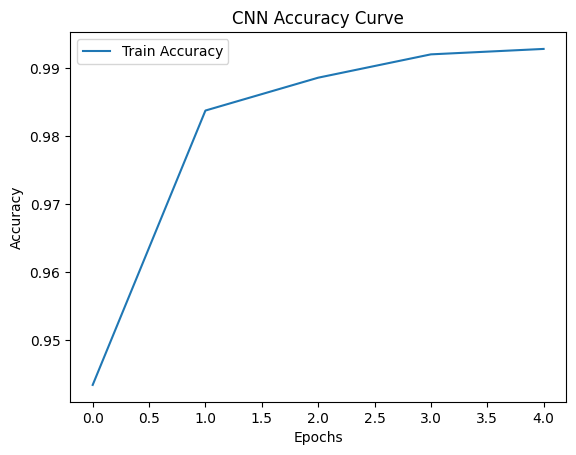

In [13]:
# plotting accuracy graph
plt.plot(history, label='Train Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy Curve")
plt.legend()
plt.show()